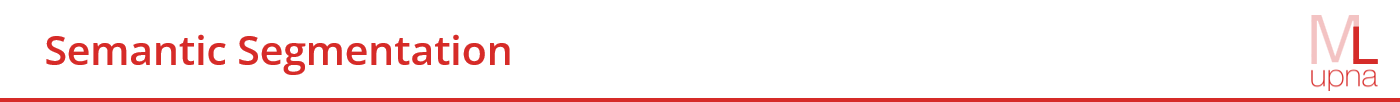

In this exercise, you will learn the fundamentals of <span style="color:#D52B29">semantic segmentation</span>, a core task in computer vision where the goal is to assign a <span style="color:#D52B29">class label</span> to each pixel of an image. Unlike classification, which predicts a single label for an entire image, or detection, which localizes objects with bounding boxes, semantic segmentation provides a much more detailed and structured understanding of visual content.

We will use the <span style="color:#D52B29">Clothing Co-Parsing (CCP)</span> dataset, which contains images of people annotated with pixel-level labels for different clothing categories. To simplify the problem and illustrate the task of segmentation, we will reduce the dataset into a <span style="color:#D52B29">binary problem</span> with only two classes: <span style="color:#D52B29">person</span> / <span style="color:#D52B29">background</span>.

![CCP Dataset](https://raw.githubusercontent.com/bearpaw/clothing-co-parsing/master/example.jpg)

Throughout the notebook, you will explore different approaches to segmentation:

- <span style="color:#D52B29">Sliding window</span> classification of the central pixel.

- <span style="color:#D52B29">Fully convolutional networks (FCNs)</span>.

- The <span style="color:#D52B29">U-Net</span> encoder-decoder architecture.

By the end of this practice, you will understand both the limitations of early approaches and the advantages of modern architectures in semantic segmentation.

## <span style="color:#D52B29">Sliding Window</span>

One of the earliest strategies for <span style="color:#D52B29">semantic segmentation</span> is the <span style="color:#D52B29">sliding window approach</span>. In this method, a fixed-size window is moved across the image, and a classifier predicts the <span style="color:#D52B29">label of the central pixel</span> based on the content inside the window.

While simple to implement, this approach, as we will see in this section, has several drawbacks:

- It is <span style="color:#D52B29">computationally expensive</span> since the network runs on many overlapping patches.

- The model often struggles to capture <span style="color:#D52B29">global context</span> because predictions are based only on local neighborhoods.

Despite these limitations, the sliding window method provides an intuitive first step toward understanding pixel-level classification.

In [1]:
# # Download from Huggingface
# !wget -q --show-progress https://huggingface.co/datasets/cayala/CCP/resolve/main/clothes.zip

# # Extract to folder
# !unzip -q clothes.zip

# # Remove the zip file
# !rm clothes.zip

In [2]:
# Buid dataset from folder structure

from glob import glob
import pandas as pd

images = glob('./clothes/*/images/*')
df = pd.DataFrame(images, columns=['image_path'])
df['mask_path'] = df.image_path.apply(lambda x : x.replace('/images/', '/labels/').replace('.jpg', '.png'))
df['set'] = df.image_path.apply(lambda x : x.split('/')[2])
df.head()

,image_path,mask_path,set
0,./clothes/test/images/0851.jpg,./clothes/test/labels/0851.png,test
1,./clothes/test/images/0852.jpg,./clothes/test/labels/0852.png,test
2,./clothes/test/images/0853.jpg,./clothes/test/labels/0853.png,test
3,./clothes/test/images/0854.jpg,./clothes/test/labels/0854.png,test
4,./clothes/test/images/0855.jpg,./clothes/test/labels/0855.png,test


In [3]:
import pandas as pd

classes = pd.read_csv("clothes/class_dict.csv")

print(classes)

     class_name    r    g    b
0           NaN   69    6   90
1   accessories   70   12   95
2           bag   71   18  101
3          belt   72   25  107
4        blazer   72   30  112
5        blouse   72   35  116
6      bodysuit   71   40  120
7         boots   70   47  124
8           bra   69   52  127
9      bracelet   68   57  130
10         cape   66   61  132
11     cardigan   64   67  135
12        clogs   62   72  136
13         coat   61   76  137
14        dress   58   82  139
15     earrings   56   86  139
16        flats   54   90  140
17      glasses   52   94  141
18       gloves   50   99  141
19         hair   48  103  141
20          hat   46  107  142
21        heels   45  111  142
22       hoodie   43  116  142
23     intimate   41  120  142
24       jacket   40  123  142
25        jeans   38  127  142
26       jumper   36  132  141
27     leggings   35  136  141
28      loafers   34  139  141
29     necklace   32  144  140
30      panties   31  148  139
31      

In [4]:
# import pandas as pd
# import io

# # Load your data
# # (Assuming 'classes' is already loaded as your DataFrame)
# # For example: classes = pd.read_csv("clothes/class_dict.csv")

# # 1. Standard One-Hot Encoding
# # This converts 'class_name' into multiple binary columns (0 or 1).
# # By default, this ignores the 'NaN' value in the first row (row 0 will be all zeros for class columns).
# encoded_classes = pd.get_dummies(classes, columns=['class_name'])

# # 2. Include NaN as a category (Optional)
# # If you want 'NaN' to have its own column (class_name_nan), set dummy_na=True.
# encoded_classes_with_na = pd.get_dummies(classes, columns=['class_name'], dummy_na=True)

# # View the results
# print(encoded_classes.head())

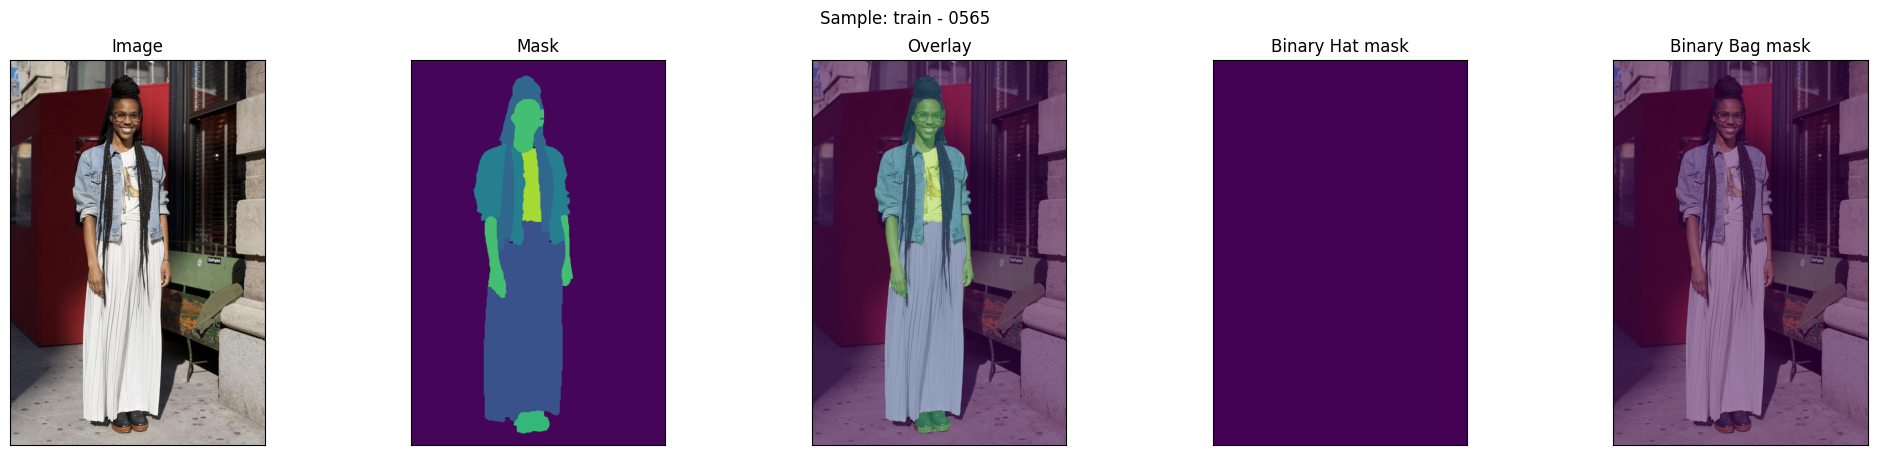

In [5]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)


f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

hat_mask = (y != np.array([46, 107, 142])).any(-1) # [69,  6, 90] RGB values = background
ax[3].imshow(hat_mask)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_title('Binary Hat mask')




bag_mask = (y != np.array([71, 18, 101])).any(-1)
    
ax[4].imshow(x)
ax[4].imshow(bag_mask, alpha=.5)
ax[4].set_xticks([])
ax[4].set_yticks([])
ax[4].set_title('Binary Bag mask')

plt.show()

We start by creating a function that extracts a <span style="color:#D52B29">random patch</span> from an image and assigns it the class corresponding to the <span style="color:#D52B29">central pixel</span> of the patch. It is important to note that, for model training, we will select <span style="color:#D52B29">random patches</span> from the images, since extracting all possible patches corresponding to every pixel in the training images would be <span style="color:#D52B29">computationally infeasible</span>.

In [6]:
def random_crop(img, mask, patch_size=224):
    """
    Take a random [patch_size, patch_size, :] window from an image [H, W, :] and corresponding mask [H, W, :].
    
    Args:
        img: numpy array of shape [H, W, :]
        mask: numpy array of shape [H, W, :]
        patch_size: patch size (int)
    
    Returns:
        img_patch: numpy array of shape [patch_size, patch_size, 3]
        mask_patch: numpy array of shape [patch_size, patch_size, 3]
    """
    H, W, _ = img.shape
        
    # Random top-left corner
    y = np.random.randint(0, H - patch_size + 1)
    x = np.random.randint(0, W - patch_size + 1)
    
    # Extract patch
    img_patch = img[y:y+patch_size, x:x+patch_size, :]
    mask_patch = mask[y:y+patch_size, x:x+patch_size, :]
    
    return img_patch, mask_patch

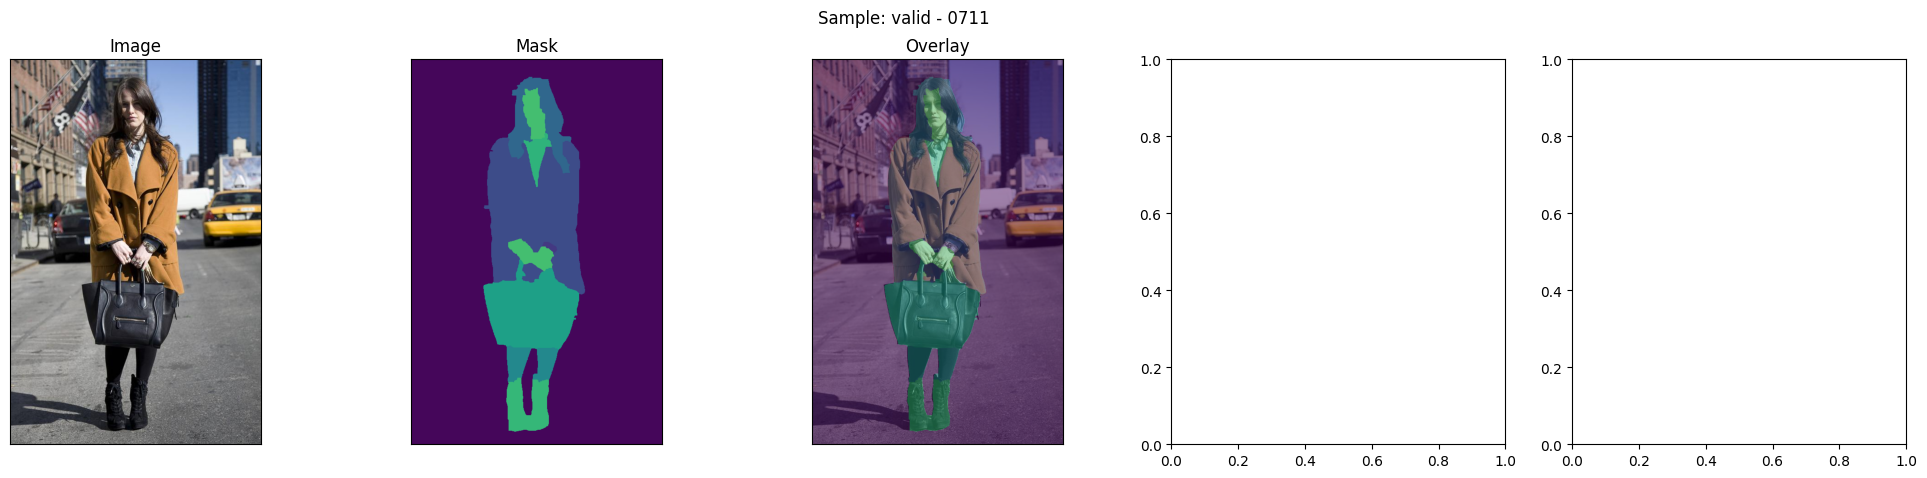

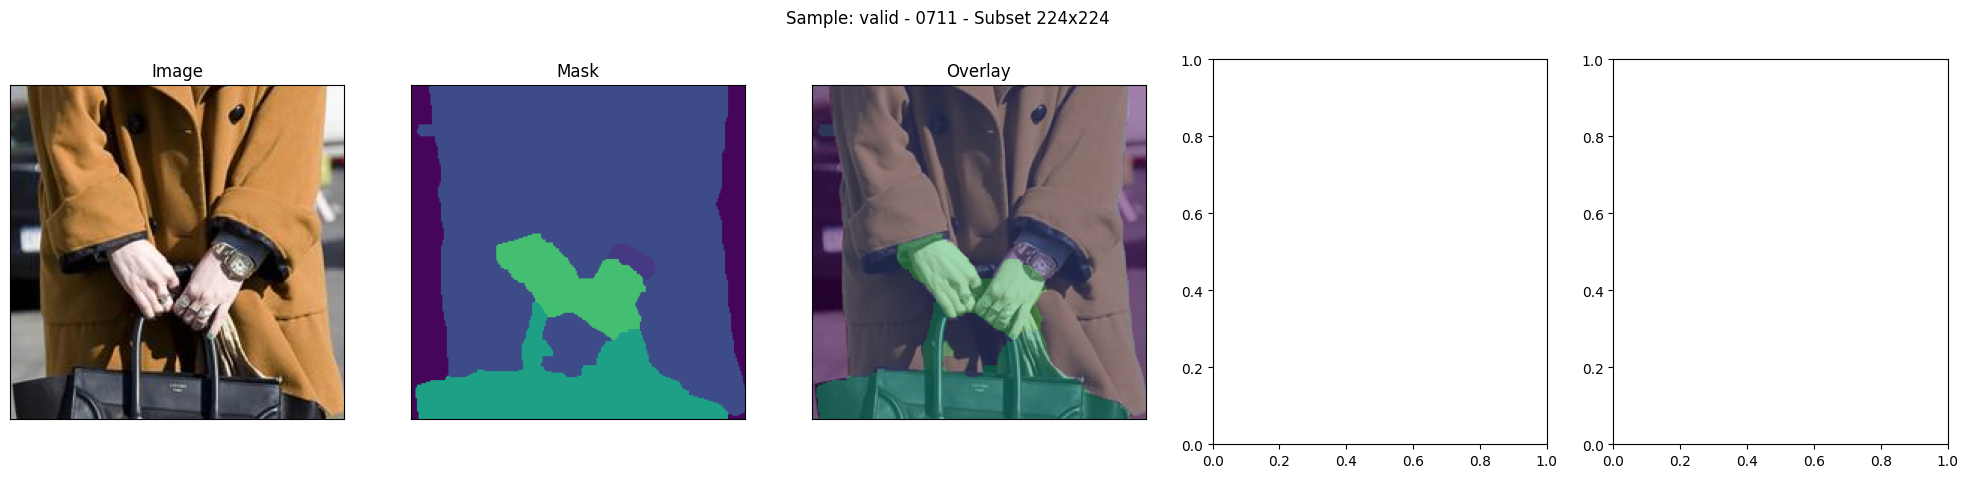

In [7]:
# Inspect a randomly taken sample
import matplotlib.pyplot as plt
from skimage.io import imread
import os
import numpy as np

r = df.sample(1).iloc[0]

x = imread(r.image_path)
y = imread(r.mask_path)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} ')

ax[0].imshow(x)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(y)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(x)
ax[2].imshow(y, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

# binary_mask = (y != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
# ax[3].imshow(binary_mask)
# ax[3].set_xticks([])
# ax[3].set_yticks([])
# ax[3].set_title('Binary Mask')

# ax[4].imshow(x)
# ax[4].imshow(binary_mask, alpha=.5)
# ax[4].set_xticks([])
# ax[4].set_yticks([])
# ax[4].set_title('Overlay')

plt.show()

# Subset

img_patch, mask_patch = random_crop(x, y, patch_size=224)

f, ax = plt.subplots(1, 5, figsize=(25, 5))

f.suptitle(f'Sample: {r.set} - {os.path.basename(r.image_path).split(".")[0]} - Subset 224x224')

ax[0].imshow(img_patch)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title('Image')

ax[1].imshow(mask_patch)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title('Mask')

ax[2].imshow(img_patch)
ax[2].imshow(mask_patch, alpha=.5)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title('Overlay')

# binary_mask_patch = (mask_patch != np.array([69,  6, 90])).any(-1) # [69,  6, 90] RGB values = background
# ax[3].imshow(binary_mask_patch)
# ax[3].set_xticks([])
# ax[3].set_yticks([])
# ax[3].set_title('Binary Mask')

# ax[4].imshow(img_patch)
# ax[4].imshow(binary_mask_patch, alpha=.5)
# ax[4].set_xticks([])
# ax[4].set_yticks([])
# ax[4].set_title('Overlay')

plt.show()

In [8]:
mask_patch.shape

(224, 224, 3)

What we will do next is create a <span style="color:#D52B29">PyTorch Dataset</span> that takes as input a <span style="color:#D52B29">DataFrame</span> where each row corresponds to one example of the dataset. The <span style="color:#D52B29">getitem()</span> function will load the example at index <span style="color:#D52B29">idx</span>. That is, it will read the image and its corresponding mask, extract a <span style="color:#D52B29">random patch of size 224×224</span>, and then apply transformations to the input image, such as <span style="color:#D52B29">normalization using ImageNet statistics</span>.

In [9]:
import torch

In [10]:
from torchvision.transforms import v2

In [11]:
from torchvision.models import ResNet18_Weights

In [12]:
weights = ResNet18_Weights.IMAGENET1K_V1
transforms = weights.transforms()
# ds = CCPDataset(df, patch_size=224, transforms=transforms)

In [13]:
# rndm_idx = torch.randint(ds.__len__(), [1]).item()
# x, y = ds.__getitem__(rndm_idx)
# ds.__show_item__(x, y)

Once we have the <span style="color:#D52B29">Dataset</span>, we can create the <span style="color:#D52B29">DataLoaders</span> using the <span style="color:#D52B29">DataModule</span> class.

In [14]:
# --- IMPORTS ---
import lightning.pytorch as pl
import torch
import numpy as np
from skimage.io import imread
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
from torchvision import tv_tensors  # <--- CRITICAL FOR MASKS

# --- DATASET ---
class CCPDataset(torch.utils.data.Dataset):

    def __init__(self, df, class_df=None, patch_size=224, transforms=None, mode='train'):
        super(CCPDataset, self).__init__()
        self.df = df
        self.ps = patch_size
        self.transforms = transforms
        self.mode = mode
        
        # 1. Multiclass LUT Setup
        if class_df is not None:
            self.color_to_class = np.zeros((256, 256, 256), dtype=np.int64)
            self.color_to_class.fill(0) 
            for index, row in class_df.iterrows():
                r, g, b = int(row['r']), int(row['g']), int(row['b'])
                self.color_to_class[r, g, b] = index
        else:
            self.color_to_class = None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Read Images
        x = imread(row.image_path)
        y = imread(row.mask_path)

        # 2. Handle Grayscale/RGBA -> RGB
        if x.ndim == 2: x = np.stack([x]*3, axis=-1)
        elif x.ndim == 3 and x.shape[2] == 4: x = x[:, :, :3]
        if y.ndim == 3 and y.shape[2] == 4: y = y[:, :, :3]

        # 3. Handle Eval Mode (Deterministic Crop)
        if self.mode == 'eval':
            r_start, c_start = row.coords
            x = x[r_start:r_start+self.ps, c_start:c_start+self.ps]
            y = y[r_start:r_start+self.ps, c_start:c_start+self.ps]
        
        # 4. Color Mapping (RGB -> Class Index)
        y_indices = self.color_to_class[y[:, :, 0], y[:, :, 1], y[:, :, 2]]

        # 5. Prepare Tensors (Wrap in tv_tensors to ensure v2 works correctly)
        x = torch.from_numpy(x).permute(2, 0, 1) # (C, H, W)
        y = torch.from_numpy(y_indices)          # (H, W)
        
        # WRAP: This tells v2 that 'y' is a Mask (use Nearest Neighbor resize)
        # and 'x' is an Image.
        x = tv_tensors.Image(x)
        y = tv_tensors.Mask(y)

        # 6. Apply Transforms
        if self.transforms:
            if isinstance(self.transforms, (tuple, list)) and len(self.transforms) == 2:
                t_joint, t_img = self.transforms
                
                if self.mode == 'train':
                    # JOINT: RandomCrop + Resize
                    # Because y is wrapped in tv_tensors.Mask, Resize works correctly!
                    x, y = t_joint(x, y) 
                    
                    # IMAGE ONLY: Normalize
                    x = t_img(x)
                else:
                    # EVAL: Just Normalize (we cropped manually above)
                    x = t_img(x)
            else:
                x = self.transforms(x)

        # 7. Final Output
        # y is likely still tv_tensors.Mask, convert to pure LongTensor
        y = y.data.long().unsqueeze(0) # (1, H, W)

        return x, y.squeeze(0) # (H, W)

    def __len__(self): 
        return self.df.shape[0]

# --- DATAMODULE (Re-define to use new CCPDataset) ---
class DataModule(pl.LightningDataModule):
    def __init__(self, df, classes, bs=64, ps=224):
        super().__init__()
        self.df = df
        self.classes = classes
        self.bs = bs
        self.ps = ps

    def patch_origins(self, h, w, ps, overlap=.5):
        if ps > h or ps > w: raise ValueError("Patch too big")
        stride = int(ps * overlap)
        if stride <= 0: raise ValueError("Stride too small")
        hs = list(range(0, h - ps + 1, stride))
        ws = list(range(0, w - ps + 1, stride))
        if hs[-1] != h - ps: hs.append(h - ps)
        if ws[-1] != w - ps: ws.append(w - ps)
        return np.array([(h, w) for h in hs for w in ws], dtype=int)

    def setup(self, stage=None): 
        # Defines transforms
        train_transforms = (
            T.Compose([
                T.RandomCrop((self.ps, self.ps)), 
                T.Resize(size=(224, 224), antialias=True), 
            ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )

        eval_transforms = (
            T.Compose([ T.Resize(size=(224, 224), antialias=True) ]),
            T.Compose([
                T.ToImage(), 
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        )
        
        # Instantiate Datasets
        self.train_ds = CCPDataset(
            df=self.df.query('set == "train"'), 
            class_df=self.classes,    
            patch_size=self.ps, 
            transforms=train_transforms,
            mode='train'
        )

        # Build Validation with Patches
        valid_df = self.df.query('set == "valid"').copy()
        valid_df['coords'] = valid_df.image_path.apply(
            lambda x : self.patch_origins(*imread(x).shape[:-1], ps=self.ps, overlap=1).tolist()
        )
        valid_df = valid_df.explode('coords')

        self.valid_ds = CCPDataset(
            df=valid_df, 
            class_df=self.classes,
            patch_size=self.ps, 
            transforms=eval_transforms, 
            mode='eval'
        )
        
        # Build Test with Patches
        test_df = self.df.query('set == "test"').copy()
        test_df['coords'] = test_df.image_path.apply(
            lambda x : self.patch_origins(*imread(x).shape[:-1], ps=self.ps, overlap=1).tolist()
        )
        test_df = test_df.explode('coords')

        self.test_ds = CCPDataset(
            df=test_df, 
            class_df=self.classes,
            patch_size=self.ps, 
            transforms=eval_transforms, 
            mode='eval'
        )

    def train_dataloader(self): 
        return DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=2)

    def val_dataloader(self): 
        return DataLoader(self.valid_ds, batch_size=self.bs, shuffle=False, num_workers=2)

    def test_dataloader(self): 
        return DataLoader(self.test_ds, batch_size=self.bs, shuffle=False, num_workers=2)

# --- EXECUTION ---
# 1. Re-instantiate DataModule (This clears the old class logic)
data_module = DataModule(df, classes, bs=64, ps=224)
data_module.setup('train')

# 2. Test
print("Testing Batch Generation...")
batch = next(iter(data_module.train_dataloader()))
print(f"Success! Batch X: {batch[0].shape}, Batch Y: {batch[1].shape}")

Testing Batch Generation...
Success! Batch X: torch.Size([64, 3, 224, 224]), Batch Y: torch.Size([64, 224, 224])


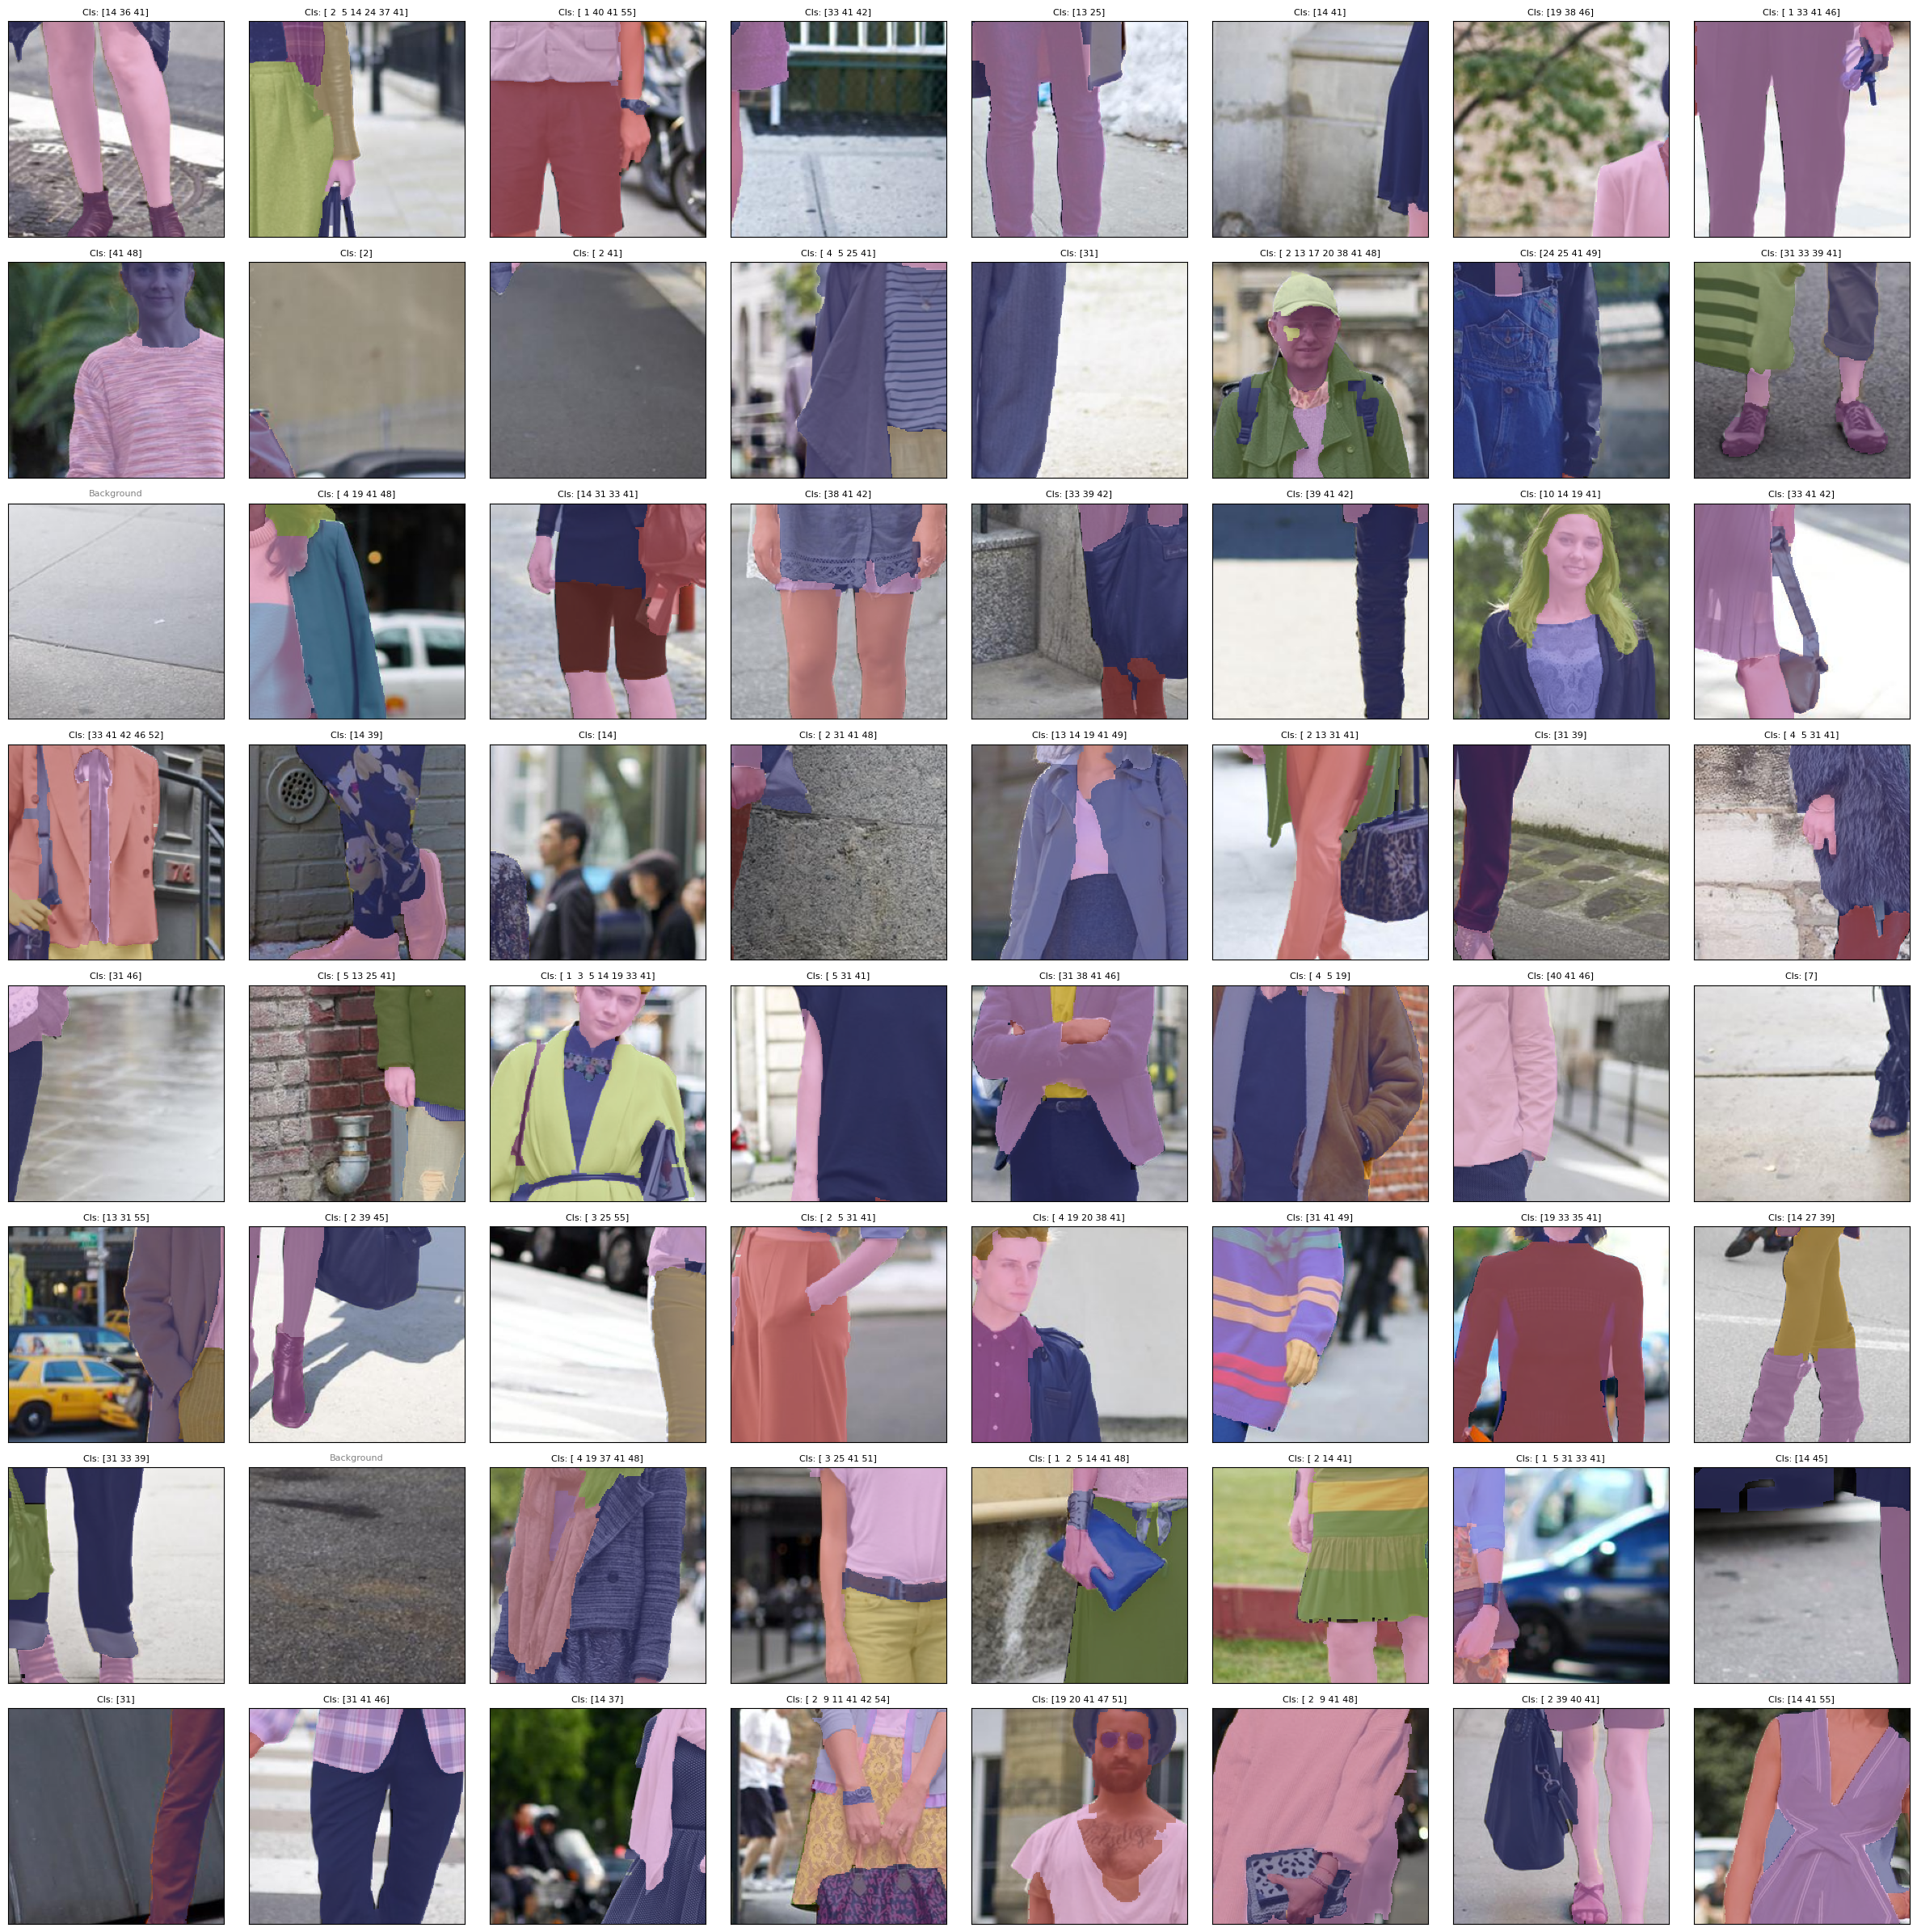

In [15]:
import matplotlib.pyplot as plt

# Define Un-Normalization (Reverse ImageNet stats)
# x_new = x * std + mean
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Get a batch
batch = next(iter(data_module.train_dataloader()))
images, masks = batch

# Setup plot
f, ax = plt.subplots(8, 8, figsize=(24, 24))
ax = ax.ravel()

for i in range(64):
    # 1. Denormalize image for display
    img_vis = denormalize(images[i]).permute(1, 2, 0).numpy()
    
    # 2. Get the mask (Integers 0-58)
    mask_vis = masks[i].numpy()
    
    # 3. Plot Image
    ax[i].imshow(img_vis)
    
    # 4. Overlay Mask (with transparency)
    # We filter out class 0 (background) so the image is visible
    masked_data = np.ma.masked_where(mask_vis == 0, mask_vis)
    ax[i].imshow(masked_data, cmap='tab20b', alpha=0.6, interpolation='nearest')
    
    # Clean up axes
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
    # Optional: Title shows unique classes found in this patch
    unique_classes = np.unique(mask_vis)
    unique_classes = unique_classes[unique_classes != 0] # Remove background
    if len(unique_classes) > 0:
        ax[i].set_title(f"Cls: {unique_classes}", fontsize=8)
    else:
        ax[i].set_title("Background", fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## <span style="color:#D52B29">Encoder-Decoder Architecture</span>

In previous sections, we saw that convolutional networks used for classification extract information from the original image at multiple levels. Each level compresses information more, producing richer features. However, in the first strategy (sliding window), this does not help for segmentation since we would need to classify pixel by pixel.

The second strategy we explored does not compress the information and works at the original resolution, allowing segmentation in a single pass. Unfortunately, it is also not ideal due to the high computational cost.

The solution is to <span style="color:#D52B29">combine both approaches</span>. We will use <span style="color:#D52B29">FCNNs that internally compress and decompress information</span>. Pooling layers reduce dimensionality (<span style="color:#D52B29">encoder</span>), while deconvolution or upsampling layers restore it (<span style="color:#D52B29">decoder</span>). Additionally, most architectures include <span style="color:#D52B29">skip-connections</span> that transfer information from the encoder to the decoder for more precise reconstruction.

Among encoder-decoder architectures, there are many variations. Fastai focuses on the most widely used one due to its strong generalization across tasks: the <span style="color:#D52B29">U-Net</span>, named after the "U" shape of its structure, as illustrated below.

![Arquitectura Unet](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Imagen from: [U-Net: Convolutional Networks for Biomedical Image Segmentation
](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/#:~:text=The%20u%2Dnet%20is%20convolutional,and%20precise%20segmentation%20of%20images.&text=U%2Dnet%20architecture%20(example%20for,on%20top%20of%20the%20box.).

As we can see, the architecture starts with a CNN-like <span style="color:#D52B29">encoder</span>, consisting of convolutional and pooling layers. This part can be replaced with any CNN we’ve seen before (e.g., <span style="color:#D52B29">ResNet</span>), also called the <span style="color:#D52B29">backbone</span>. After compression, the <span style="color:#D52B29">decoder</span> uses upsampling and convolutional layers to restore spatial resolution. The horizontal arrows are <span style="color:#D52B29">skip-connections</span>, which pass features from each encoder level to the corresponding decoder layer, improving spatial accuracy.

Although there are technical complexities like undoing pooling (<span style="color:#D52B29">upsampling</span>) or implementing deconvolutions, these details are abstracted when using Fastai’s <span style="color:#D52B29">U-Net</span> implementation, so we will focus on its practical use rather than the low-level operations.

To implement the <span style="color:#D52B29">U-Net</span> and other more advanced semantic segmentation architectures, we will use the <span style="color:#D52B29">Segmentation Models PyTorch</span> library. This library allows us to easily choose different encoders and configure various internal parameters of the network.

Next, we will see how to instantiate a <span style="color:#D52B29">U-Net</span> that uses a <span style="color:#D52B29">ResNet18 encoder</span> pre-trained on ImageNet.

In [16]:
!uv pip install segmentation_models_pytorch

Using Python 3.13.7 environment at: /home/alumno/py313ml/.venv
Audited 1 package in 6ms


In [17]:
import segmentation_models_pytorch as smp

In [18]:
n_classes = len(classes)

In [19]:
# model = smp.Unet(
#     encoder_name='resnet18',
#     encoder_weights='imagenet',
#     in_channels=3,
#     classes=n_classes
# )

# model

In [20]:
# x = torch.rand(1, 3, 256, 256)
# y_hat = model(x)
# y_hat.shape

We are now going to modify the <span style="color:#D52B29">LightningModule</span> to make use of this new <span style="color:#D52B29">U-Net model</span> and train it with the same parametrization as in the previous experiments, ensuring a <span style="color:#D52B29">fair comparison</span>.

## Trying the new models

In [22]:
class CCP_SegmentationModel(pl.LightningModule):
    def __init__(self, model, n_classes=59):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        
        self.model = model

        # FIX 1: Assign FocalLoss correctly. 
        # Note: No 'from_logits=True' needed here, SMP handles it.
        self.loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        # FIX 2: Lower Learning Rate to prevent collapse
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        # Shape Check
        if y.ndim == 4: y = y.squeeze(1)
            
        loss = self.loss_fn(logits, y)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        if y.ndim == 4: y = y.squeeze(1)

        loss = self.loss_fn(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

ERROR! Session/line number was not unique in database. History logging moved to new session 6


In [23]:
from lightning.pytorch.loggers import CSVLogger
import os

unetplusplus_model = smp.UnetPlusPlus(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

upernet_model = smp.UPerNet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

deeplab_model = smp.DeepLabV3Plus(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

models = [unetplusplus_model, upernet_model, deeplab_model]
names = ["Unet++", "UPerNet", "DeepLabV3+"]
# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

for model, name in zip(models, names):

    # Intantiate LightningModule
    lightning_module = CCP_SegmentationModel(model)
    
    # Define a CSV logger to store training/validation metrics in CSV format.
    csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_"+name)
    
    # Define a checkpoint callback:
    # It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
    model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
        monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)
    
    # Create a PyTorch Lightning trainer
    trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])
    
    # Load the data module
    data_module = DataModule(df, classes, bs=64, ps=224)#, transforms=transforms)
    
    torch.set_float32_matmul_precision('medium')
    
    # Train the model with the trainer, passing the core LightningModule and data module.
    trainer.fit(lightning_module, data_module)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type         | Params | Mode 
-------------------------------------------------
0 | model   | UnetPlusPlus | 16.0 M | train
1 | loss_fn | DiceLoss     | 0      | train
-------------------------------------------------
16.0 M    Trainable params
0         Non-trainable params
16.0 M    Total params
63.915    Total estimated model params size (MB)
219       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (11) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Epoch 27, global step 308: 'val_loss' was not in top 1


Validation: |                                             | 0/? [00:00<?, ?it/s]

Epoch 28, global step 319: 'val_loss' was not in top 1


Validation: |                                             | 0/? [00:00<?, ?it/s]

Epoch 29, global step 330: 'val_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


We will now load the best model and perform inference as before, in order to compute metrics and compare this approach with the previous ones.


Processing: Unet++
✅ Saved convergence plot for Unet++
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_Unet++/version_2/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for Unet++...


Results for Unet++:
pixel_acc        0.824646
iou_macro        0.091503
iou_weighted     0.786061
dice_macro         0.1104
dice_weighted    0.832251
Model              Unet++
dtype: object

Processing: UPerNet
✅ Saved convergence plot for UPerNet
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_UPerNet/version_1/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for UPerNet...


Results for UPerNet:
pixel_acc        0.816064
iou_macro        0.114384
iou_weighted     0.781481
dice_macro       0.139347
dice_weighted    0.826222
Model             UPerNet
dtype: object

Processing: DeepLabV3+
✅ Saved convergence plot for DeepLabV3+
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_DeepLabV3+/version_0/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for DeepLabV3+...


Results for DeepLabV3+:
pixel_acc          0.815209
iou_macro          0.101004
iou_weighted       0.779239
dice_macro         0.122899
dice_weighted      0.825991
Model            DeepLabV3+
dtype: object

FINAL LEADERBOARD
            pixel_acc  iou_macro  iou_weighted  dice_macro  dice_weighted
Model                                                                    
Unet++       0.824646   0.091503      0.786061    0.110400       0.832251
UPerNet      0.816064   0.114384      0.781481    0.139347       0.826222
DeepLabV3+   0.815209   0.101004      0.779239    0.122899       0.825991


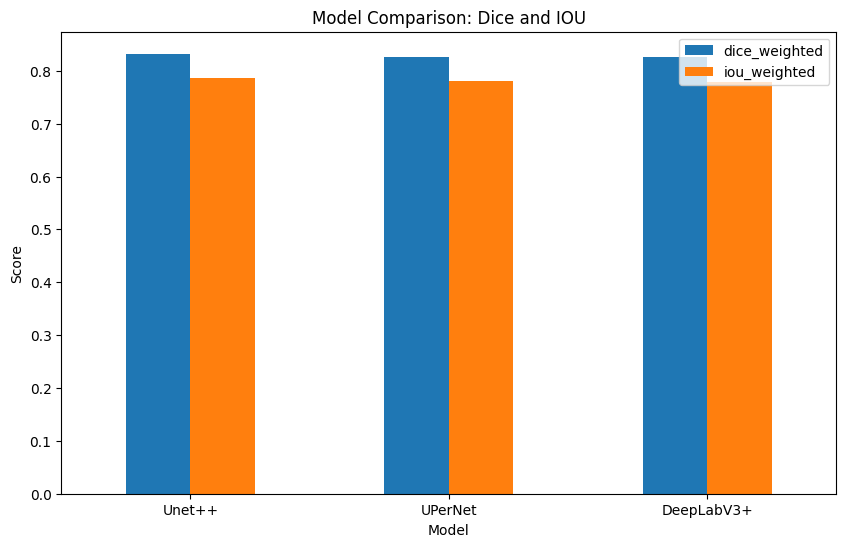

In [32]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.v2 as T
from fastprogress import master_bar, progress_bar
from torch import nn
from skimage.io import imread
from sklearn.metrics import accuracy_score, jaccard_score, f1_score
import segmentation_models_pytorch as smp
import glob
import os

# --- 1. GLOBAL SETUP (Run Once) ---

# Color Mapping
color_to_class = np.zeros((256, 256, 256), dtype=np.int64)
color_to_class.fill(0) 
for index, row in classes.iterrows():
    r, g, b = int(row['r']), int(row['g']), int(row['b'])
    color_to_class[r, g, b] = index

# Transforms
ps = 224
n_classes = 59 
inf_transforms = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Define the Names used in training
model_names = ["Unet++", "UPerNet", "DeepLabV3+"]
final_results = []

# --- 2. LOOP THROUGH MODELS ---

for name in model_names:
    print(f"\n{'='*20}\nProcessing: {name}\n{'='*20}")
    
    # A. LOCATE LOGS AND CHECKPOINTS
    # Construct folder name used in training: "ccp_Unet++_imp"
    log_folder = f"ccp_{name}"
    search_path = os.path.join(os.getcwd(), log_folder, "version_*")
    versions = sorted(glob.glob(search_path))
    
    if not versions:
        print(f"❌ No logs found for {name}. Skipping.")
        continue
        
    latest_version = versions[-1]
    metrics_csv_path = os.path.join(latest_version, "metrics.csv")
    ckpt_path = os.path.join(latest_version, "checkpoints", "best_valid_loss.ckpt")
    
    # B. PLOT TRAINING CURVES
    try:
        metric_df = pd.read_csv(metrics_csv_path)
        # Consolidate epoch rows
        metric_df = metric_df.groupby('epoch', as_index=False).first() 
        
        f, ax = plt.subplots(1, 1, figsize=(10, 5))
        metric_df.train_loss.plot(ax=ax, color='blue', label='train')
        metric_df.val_loss.plot(ax=ax, color='orange', label='val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (Focal)')
        ax.set_title(f'Convergence: {name}')
        ax.legend()
        plt.savefig(f"convergence_{name}.png", dpi=200)
        plt.close() # Close plot to save memory
        print(f"✅ Saved convergence plot for {name}")
    except Exception as e:
        print(f"⚠️ Could not plot metrics for {name}: {e}")

    

    # C. RE-INSTANTIATE ARCHITECTURE
    # We must recreate the specific object to pass into load_from_checkpoint
    if name == "Unet++":
        arch = smp.UnetPlusPlus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
    elif name == "UPerNet":
        arch = smp.UPerNet(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
    elif name == "DeepLabV3+":
        arch = smp.DeepLabV3Plus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)

    # D. LOAD CHECKPOINT
    print(f"Loading weights from: {ckpt_path}")
    try:
        # CRITICAL: Pass 'model=arch' because we ignored it in save_hyperparameters
        best_model = CCP_SegmentationModel.load_from_checkpoint(
            checkpoint_path=ckpt_path,
            model=arch,
            n_classes=n_classes
        )
        best_model.eval()
        best_model.cuda()
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")
        continue

    # E. RUN INFERENCE LOOP
    print(f"Running Inference on Test Set for {name}...")
    metric_dict = []
    test_df = df.query('set == "test"')
    mb = master_bar(test_df.iterrows(), total=test_df.shape[0])

    for i, r in mb:
        # Read image and mask
        x = imread(r.image_path)
        y = imread(r.mask_path)
        
        # --- Safety Fixes ---
        if x.ndim == 2: x = np.stack([x]*3, axis=-1)
        elif x.ndim == 3 and x.shape[2] == 4: x = x[:, :, :3]
        if y.ndim == 3 and y.shape[2] == 4: y = y[:, :, :3]

        # Ground Truth indices
        y_true = color_to_class[y[:, :, 0], y[:, :, 1], y[:, :, 2]]
        
        # Sliding Window Config
        h, w = y_true.shape
        coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()
        
        # Accumulators
        y_hat = torch.zeros((n_classes, h, w), dtype=torch.float32, device='cuda')
        y_wei = torch.zeros((1, h, w), dtype=torch.float32, device='cuda') 
        
        # Patch Loop
        for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
            xi = inf_transforms(xi) # To Tensor + Normalize

            with torch.no_grad():
                logits = best_model(xi.unsqueeze(0).cuda())
                probs = nn.Softmax(dim=1)(logits)[0] 

            y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += probs
            y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

        # Aggregate and Argmax
        y_hat /= y_wei
        y_hat_indices = y_hat.argmax(0).cpu().numpy()

        # Metrics for this image
        metric_dict.append({
            'Model': name,
            'pixel_acc': accuracy_score(y_true.ravel(), y_hat_indices.ravel()),
            'iou_macro': jaccard_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0),
            'iou_weighted': jaccard_score(y_true.ravel(), y_hat_indices.ravel(), average='weighted', zero_division=0),
            'dice_macro': f1_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0),
            'dice_weighted': f1_score(y_true.ravel(), y_hat_indices.ravel(), average='weighted', zero_division=0)
        })

    # Average metrics for this model
    model_mean = pd.DataFrame(metric_dict).mean(numeric_only=True)
    model_mean['Model'] = name # Add name back
    final_results.append(model_mean)
    print(f"Results for {name}:\n{model_mean}")

# --- 3. FINAL COMPARISON ---
print("\n" + "="*30)
print("FINAL LEADERBOARD")
print("="*30)
leaderboard = pd.DataFrame(final_results).set_index('Model')
print(leaderboard)

# Optional: Visual Comparison
leaderboard[['dice_weighted', 'iou_weighted']].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison: Dice and IOU")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig("comparison_initial_models.png", dpi=250)
plt.show()

🏆 The Best Model is: Unet++
Generating prediction for Unet++...
Saved visualization to best_prediction_Unet++.png


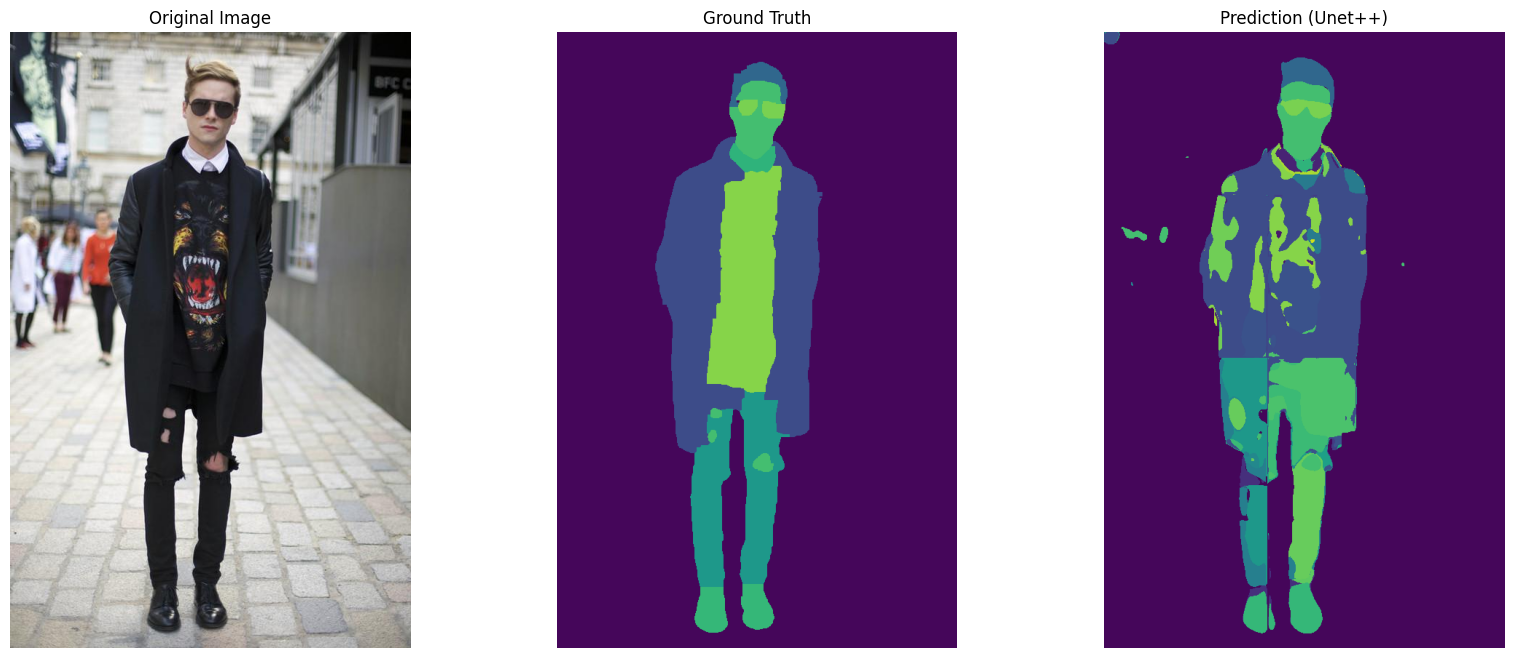

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.io import imread

# 1. Identify the Best Model from the Leaderboard
# We use Weighted IoU as the deciding metric
best_model_name = leaderboard['iou_weighted'].idxmax()
print(f"🏆 The Best Model is: {best_model_name}")

# 2. Locate the Checkpoint for the Best Model
log_folder = f"ccp_{best_model_name}"
versions = sorted(glob.glob(os.path.join(os.getcwd(), log_folder, "version_*")))
best_ckpt_path = os.path.join(versions[-1], "checkpoints", "best_valid_loss.ckpt")

# 3. Re-Instantiate the Architecture for the Best Model
if best_model_name == "Unet++":
    best_arch = smp.UnetPlusPlus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
elif best_model_name == "UPerNet":
    best_arch = smp.UPerNet(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
elif best_model_name == "DeepLabV3+":
    best_arch = smp.DeepLabV3Plus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)

# 4. Load Weights
best_model_loaded = CCP_SegmentationModel.load_from_checkpoint(
    checkpoint_path=best_ckpt_path,
    model=best_arch,
    n_classes=n_classes
)
best_model_loaded.eval()
best_model_loaded.cuda()

# 5. Pick a Sample Image to Visualize
# Let's pick a random one from the test set
random_row = df.query('set == "test"').sample(1).iloc[0]

# --- RUN INFERENCE ON THIS SAMPLE ---
x_vis = imread(random_row.image_path)
y_vis = imread(random_row.mask_path)

# Safety checks
if x_vis.ndim == 2: x_vis = np.stack([x_vis]*3, axis=-1)
elif x_vis.ndim == 3 and x_vis.shape[2] == 4: x_vis = x_vis[:, :, :3]
if y_vis.ndim == 3 and y_vis.shape[2] == 4: y_vis = y_vis[:, :, :3]

# Ground Truth indices
y_true_vis = color_to_class[y_vis[:, :, 0], y_vis[:, :, 1], y_vis[:, :, 2]]

# Sliding Window Logic
h, w = y_true_vis.shape
coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()
y_hat_vis = torch.zeros((n_classes, h, w), dtype=torch.float32, device='cuda')
y_wei_vis = torch.zeros((1, h, w), dtype=torch.float32, device='cuda')

print(f"Generating prediction for {best_model_name}...")
for (coord_x, coord_y) in coords:
    xi = x_vis[coord_x:coord_x+ps, coord_y:coord_y+ps]
    xi = inf_transforms(xi)
    with torch.no_grad():
        logits = best_model_loaded(xi.unsqueeze(0).cuda())
        probs = nn.Softmax(dim=1)(logits)[0]
    y_hat_vis[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += probs
    y_wei_vis[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

y_hat_vis /= y_wei_vis
y_pred_vis = y_hat_vis.argmax(0).cpu().numpy()

# --- 6. VISUALIZATION FUNCTION ---

def decode_segmap(mask_indices, class_df):
    h, w = mask_indices.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    # Loop only through the unique classes present in this mask
    for idx in np.unique(mask_indices):
        if 0 <= idx < len(class_df):
            color = class_df.iloc[idx][['r', 'g', 'b']].values
            rgb_mask[mask_indices == idx] = color
    return rgb_mask

# Decode
rgb_true_vis = decode_segmap(y_true_vis, classes)
rgb_pred_vis = decode_segmap(y_pred_vis, classes)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

# Original Image
ax[0].imshow(x_vis)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(rgb_true_vis)
ax[1].set_title("Ground Truth")
ax[1].axis('off')

# Prediction
ax[2].imshow(rgb_pred_vis)
ax[2].set_title(f"Prediction ({best_model_name})")
ax[2].axis('off')

save_name = f"best_prediction_{best_model_name}.png"
plt.savefig(save_name, dpi=400, bbox_inches='tight')
print(f"Saved visualization to {save_name}")
plt.show()

As we can see, the results obtained with <span style="color:#D52B29">U-Net</span> are the best so far. We not only gain in <span style="color:#D52B29">efficiency</span> but also in <span style="color:#D52B29">accuracy</span>. This strategy is therefore the one we should follow to tackle <span style="color:#D52B29">semantic segmentation</span> problems.

| Experiment      | Inference time    | Sample | Accuracy | IoU  | Dice |
|:---------------:|:----------------:|:------:|:--------:|:----:|:----:|
| Sliding Window  | 30m* / image     | 0851   | 83.89    | 0.56 | 0.71 |
| FCNN            | 1s / image       | 0851   | 79.76    | 0.34 | 0.51 |
| U-Net           | 1s / image       | 0851   | 94.98    | 0.81 | 0.89 |

*Inference time for the sliding window approach may be reduced applying batches.

There are, of course, other <span style="color:#D52B29">semantic segmentation</span> architectures besides U-Net (although most share the same <span style="color:#D52B29">encoder-decoder</span> principle). The <span style="color:#D52B29">segmentation models pytorch</span> library makes it easy to try out different configurations. I encourage you to experiment with them!

## Upgrading the model
- Use Focal Loss instead of Dice Loss
- Lower LR from 1e-4 to 1e-3

In [27]:
class CCP_SegmentationModel_Improved(pl.LightningModule):
    def __init__(self, model, n_classes=59):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        
        # self.model = smp.DeepLabV3Plus(
        #     encoder_name='resnet18',
        #     encoder_weights='imagenet',
        #     in_channels=3,
        #     classes=n_classes
        # )
        self.model = model

        # FIX 1: Assign FocalLoss correctly. 
        # Note: No 'from_logits=True' needed here, SMP handles it.
        # self.loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=False)
        self.loss_fn = smp.losses.FocalLoss(mode='multiclass', normalized=False) # setting this to true made the loss almost 0

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        # FIX 2: Lower Learning Rate to prevent collapse
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        return {"optimizer": optimizer}

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        
        # Shape Check
        if y.ndim == 4: y = y.squeeze(1)
            
        loss = self.loss_fn(logits, y)
        
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        if y.ndim == 4: y = y.squeeze(1)

        loss = self.loss_fn(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

In [ ]:
from lightning.pytorch.loggers import CSVLogger
import os

unetplusplus_model = smp.UnetPlusPlus(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

upernet_model = smp.UPerNet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

deeplab_model = smp.DeepLabV3Plus(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=n_classes
        )

# models = [unetplusplus_model, upernet_model, deeplab_model]
models = [deeplab_model]
# names = ["Unet++", "UPerNet", "DeepLabV3+"]
names = ["DeepLabV3+"]
# Set random seed for reproducibility
pl.seed_everything(seed=42, workers=True)

for model, name in zip(models, names):

    # Intantiate LightningModule
    lightning_module = CCP_SegmentationModel_Improved(model)
    
    # Define a CSV logger to store training/validation metrics in CSV format.
    csv_logger = CSVLogger(save_dir=os.getcwd(), name="ccp_"+name+"_imp")
    
    # Define a checkpoint callback:
    # It will save the model with the lowest validation loss ("best_valid_loss.ckpt").
    model_checkpoint_callback = pl.callbacks.model_checkpoint.ModelCheckpoint(
        monitor='val_loss',mode='min', filename='best_valid_loss', verbose=True, save_last=False)
    
    # Create a PyTorch Lightning trainer
    trainer = pl.Trainer(max_epochs=30, logger=csv_logger, callbacks=[model_checkpoint_callback])
    
    # Load the data module
    data_module = DataModule(df, classes, bs=64, ps=224)#, transforms=transforms)
    
    torch.set_float32_matmul_precision('medium')
    
    # Train the model with the trainer, passing the core LightningModule and data module.
    trainer.fit(lightning_module, data_module)


Processing: Unet++
✅ Saved convergence plot for Unet++
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_Unet++_imp/version_1/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for Unet++...


Results for Unet++:
pixel_acc        0.783665
iou_macro        0.064629
iou_weighted     0.759031
dice_macro       0.076154
dice_weighted    0.791651
Model              Unet++
dtype: object

Processing: UPerNet
✅ Saved convergence plot for UPerNet
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_UPerNet_imp/version_0/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for UPerNet...


Results for UPerNet:
pixel_acc        0.861001
iou_macro        0.172887
iou_weighted     0.826328
dice_macro       0.207967
dice_weighted    0.861656
Model             UPerNet
dtype: object

Processing: DeepLabV3+
✅ Saved convergence plot for DeepLabV3+
Loading weights from: /home/alumno/Desktop/datos/Computer Vision/ccp_DeepLabV3+_imp/version_1/checkpoints/best_valid_loss.ckpt
Running Inference on Test Set for DeepLabV3+...


Results for DeepLabV3+:
pixel_acc          0.856427
iou_macro          0.174087
iou_weighted       0.816445
dice_macro         0.210101
dice_weighted      0.853564
Model            DeepLabV3+
dtype: object

FINAL LEADERBOARD
            pixel_acc  iou_macro  iou_weighted  dice_macro  dice_weighted
Model                                                                    
Unet++       0.783665   0.064629      0.759031    0.076154       0.791651
UPerNet      0.861001   0.172887      0.826328    0.207967       0.861656
DeepLabV3+   0.856427   0.174087      0.816445    0.210101       0.853564


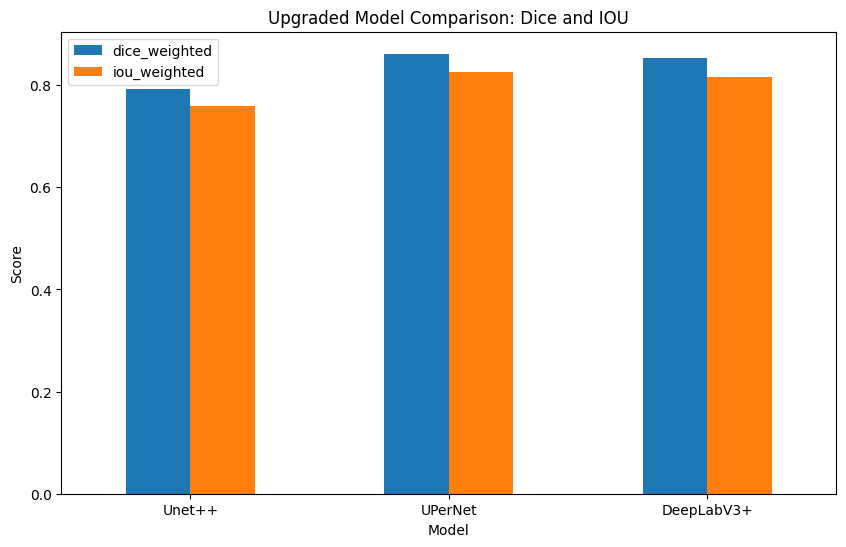

In [33]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.v2 as T
from fastprogress import master_bar, progress_bar
from torch import nn
from skimage.io import imread
from sklearn.metrics import accuracy_score, jaccard_score, f1_score
import segmentation_models_pytorch as smp
import glob
import os

# --- 1. GLOBAL SETUP (Run Once) ---

# Color Mapping
color_to_class = np.zeros((256, 256, 256), dtype=np.int64)
color_to_class.fill(0) 
for index, row in classes.iterrows():
    r, g, b = int(row['r']), int(row['g']), int(row['b'])
    color_to_class[r, g, b] = index

# Transforms
ps = 224
n_classes = 59 
inf_transforms = T.Compose([
    T.ToImage(), 
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Define the Names used in training
model_names = ["Unet++", "UPerNet", "DeepLabV3+"]
final_results = []

# --- 2. LOOP THROUGH MODELS ---

for name in model_names:
    print(f"\n{'='*20}\nProcessing: {name}\n{'='*20}")
    
    # A. LOCATE LOGS AND CHECKPOINTS
    # Construct folder name used in training: "ccp_Unet++_imp"
    log_folder = f"ccp_{name}_imp"
    search_path = os.path.join(os.getcwd(), log_folder, "version_*")
    versions = sorted(glob.glob(search_path))
    
    if not versions:
        print(f"❌ No logs found for {name}. Skipping.")
        continue
        
    latest_version = versions[-1]
    metrics_csv_path = os.path.join(latest_version, "metrics.csv")
    ckpt_path = os.path.join(latest_version, "checkpoints", "best_valid_loss.ckpt")
    
    # B. PLOT TRAINING CURVES
    try:
        metric_df = pd.read_csv(metrics_csv_path)
        # Consolidate epoch rows
        metric_df = metric_df.groupby('epoch', as_index=False).first() 
        
        f, ax = plt.subplots(1, 1, figsize=(10, 5))
        metric_df.train_loss.plot(ax=ax, color='blue', label='train')
        metric_df.val_loss.plot(ax=ax, color='orange', label='val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss (Focal)')
        ax.set_title(f'Convergence: {name} upgraded')
        ax.legend()
        plt.savefig(f"convergence_{name}_imp.png", dpi=200)
        plt.close() # Close plot to save memory
        print(f"✅ Saved convergence plot for {name}")
    except Exception as e:
        print(f"⚠️ Could not plot metrics for {name}: {e}")

    

    # C. RE-INSTANTIATE ARCHITECTURE
    # We must recreate the specific object to pass into load_from_checkpoint
    if name == "Unet++":
        arch = smp.UnetPlusPlus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
    elif name == "UPerNet":
        arch = smp.UPerNet(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
    elif name == "DeepLabV3+":
        arch = smp.DeepLabV3Plus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)

    # D. LOAD CHECKPOINT
    print(f"Loading weights from: {ckpt_path}")
    try:
        # CRITICAL: Pass 'model=arch' because we ignored it in save_hyperparameters
        best_model = CCP_SegmentationModel_Improved.load_from_checkpoint(
            checkpoint_path=ckpt_path,
            model=arch,
            n_classes=n_classes
        )
        best_model.eval()
        best_model.cuda()
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")
        continue

    # E. RUN INFERENCE LOOP
    print(f"Running Inference on Test Set for {name}...")
    metric_dict = []
    test_df = df.query('set == "test"')
    mb = master_bar(test_df.iterrows(), total=test_df.shape[0])

    for i, r in mb:
        # Read image and mask
        x = imread(r.image_path)
        y = imread(r.mask_path)
        
        # --- Safety Fixes ---
        if x.ndim == 2: x = np.stack([x]*3, axis=-1)
        elif x.ndim == 3 and x.shape[2] == 4: x = x[:, :, :3]
        if y.ndim == 3 and y.shape[2] == 4: y = y[:, :, :3]

        # Ground Truth indices
        y_true = color_to_class[y[:, :, 0], y[:, :, 1], y[:, :, 2]]
        
        # Sliding Window Config
        h, w = y_true.shape
        coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()
        
        # Accumulators
        y_hat = torch.zeros((n_classes, h, w), dtype=torch.float32, device='cuda')
        y_wei = torch.zeros((1, h, w), dtype=torch.float32, device='cuda') 
        
        # Patch Loop
        for (coord_x, coord_y) in progress_bar(coords, parent=mb):
            xi = x[coord_x:coord_x+ps, coord_y:coord_y+ps]
            xi = inf_transforms(xi) # To Tensor + Normalize

            with torch.no_grad():
                logits = best_model(xi.unsqueeze(0).cuda())
                probs = nn.Softmax(dim=1)(logits)[0] 

            y_hat[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += probs
            y_wei[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

        # Aggregate and Argmax
        y_hat /= y_wei
        y_hat_indices = y_hat.argmax(0).cpu().numpy()

        # Metrics for this image
        metric_dict.append({
            'Model': name,
            'pixel_acc': accuracy_score(y_true.ravel(), y_hat_indices.ravel()),
            'iou_macro': jaccard_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0),
            'iou_weighted': jaccard_score(y_true.ravel(), y_hat_indices.ravel(), average='weighted', zero_division=0),
            'dice_macro': f1_score(y_true.ravel(), y_hat_indices.ravel(), average='macro', zero_division=0),
            'dice_weighted': f1_score(y_true.ravel(), y_hat_indices.ravel(), average='weighted', zero_division=0)
        })

    # Average metrics for this model
    model_mean = pd.DataFrame(metric_dict).mean(numeric_only=True)
    model_mean['Model'] = name # Add name back
    final_results.append(model_mean)
    print(f"Results for {name}:\n{model_mean}")

# --- 3. FINAL COMPARISON ---
print("\n" + "="*30)
print("FINAL LEADERBOARD")
print("="*30)
leaderboard = pd.DataFrame(final_results).set_index('Model')
print(leaderboard)

# Optional: Visual Comparison
leaderboard[['dice_weighted', 'iou_weighted']].plot(kind='bar', figsize=(10,6))
plt.title("Upgraded Model Comparison: Dice and IOU")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig("comparison_upgraded_models.png", dpi=250)
plt.show()

🏆 The Best Model is: UPerNet
Generating prediction for UPerNet...
Saved visualization to best_prediction_UPerNet_imp.png


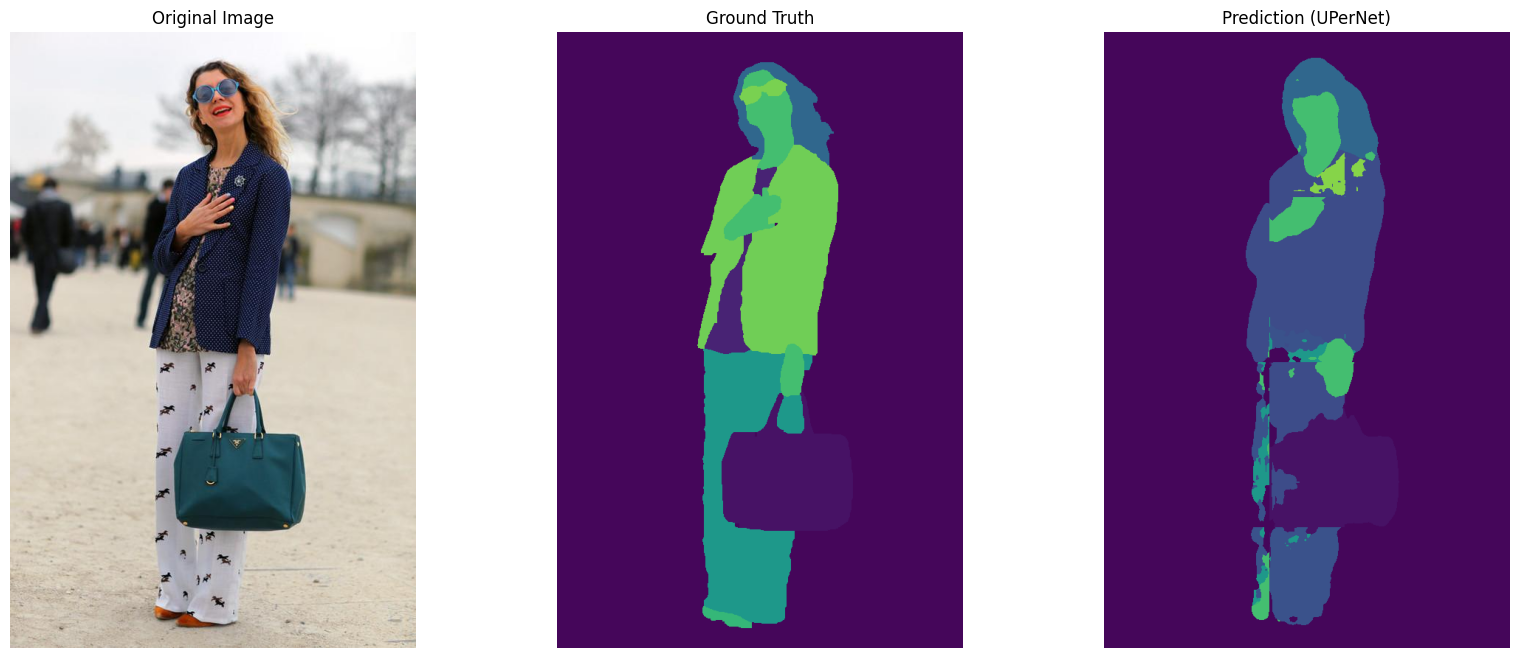

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.io import imread

# 1. Identify the Best Model from the Leaderboard
# We use Weighted IoU as the deciding metric
best_model_name = leaderboard['iou_weighted'].idxmax()
print(f"🏆 The Best Model is: {best_model_name}")

# 2. Locate the Checkpoint for the Best Model
log_folder = f"ccp_{best_model_name}_imp"
versions = sorted(glob.glob(os.path.join(os.getcwd(), log_folder, "version_*")))
best_ckpt_path = os.path.join(versions[-1], "checkpoints", "best_valid_loss.ckpt")

# 3. Re-Instantiate the Architecture for the Best Model
if best_model_name == "Unet++":
    best_arch = smp.UnetPlusPlus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
elif best_model_name == "UPerNet":
    best_arch = smp.UPerNet(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)
elif best_model_name == "DeepLabV3+":
    best_arch = smp.DeepLabV3Plus(encoder_name='resnet18', encoder_weights='imagenet', in_channels=3, classes=n_classes)

# 4. Load Weights
best_model_loaded = CCP_SegmentationModel.load_from_checkpoint(
    checkpoint_path=best_ckpt_path,
    model=best_arch,
    n_classes=n_classes
)
best_model_loaded.eval()
best_model_loaded.cuda()

# 5. Pick a Sample Image to Visualize
# Let's pick a random one from the test set
random_row = df.query('set == "test"').sample(1).iloc[0]

# --- RUN INFERENCE ON THIS SAMPLE ---
x_vis = imread(random_row.image_path)
y_vis = imread(random_row.mask_path)

# Safety checks
if x_vis.ndim == 2: x_vis = np.stack([x_vis]*3, axis=-1)
elif x_vis.ndim == 3 and x_vis.shape[2] == 4: x_vis = x_vis[:, :, :3]
if y_vis.ndim == 3 and y_vis.shape[2] == 4: y_vis = y_vis[:, :, :3]

# Ground Truth indices
y_true_vis = color_to_class[y_vis[:, :, 0], y_vis[:, :, 1], y_vis[:, :, 2]]

# Sliding Window Logic
h, w = y_true_vis.shape
coords = DataModule.patch_origins(None, h, w, ps=ps, overlap=1).tolist()
y_hat_vis = torch.zeros((n_classes, h, w), dtype=torch.float32, device='cuda')
y_wei_vis = torch.zeros((1, h, w), dtype=torch.float32, device='cuda')

print(f"Generating prediction for {best_model_name}...")
for (coord_x, coord_y) in coords:
    xi = x_vis[coord_x:coord_x+ps, coord_y:coord_y+ps]
    xi = inf_transforms(xi)
    with torch.no_grad():
        logits = best_model_loaded(xi.unsqueeze(0).cuda())
        probs = nn.Softmax(dim=1)(logits)[0]
    y_hat_vis[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += probs
    y_wei_vis[:, coord_x:coord_x+ps, coord_y:coord_y+ps] += 1

y_hat_vis /= y_wei_vis
y_pred_vis = y_hat_vis.argmax(0).cpu().numpy()

# --- 6. VISUALIZATION FUNCTION ---

def decode_segmap(mask_indices, class_df):
    h, w = mask_indices.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    # Loop only through the unique classes present in this mask
    for idx in np.unique(mask_indices):
        if 0 <= idx < len(class_df):
            color = class_df.iloc[idx][['r', 'g', 'b']].values
            rgb_mask[mask_indices == idx] = color
    return rgb_mask

# Decode
rgb_true_vis = decode_segmap(y_true_vis, classes)
rgb_pred_vis = decode_segmap(y_pred_vis, classes)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

# Original Image
ax[0].imshow(x_vis)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(rgb_true_vis)
ax[1].set_title("Ground Truth")
ax[1].axis('off')

# Prediction
ax[2].imshow(rgb_pred_vis)
ax[2].set_title(f"Prediction ({best_model_name})")
ax[2].axis('off')

save_name = f"best_prediction_{best_model_name}_imp.png"
plt.savefig(save_name, dpi=400, bbox_inches='tight')
print(f"Saved visualization to {save_name}")
plt.show()

## Best model
- Apply TTA
- Try removing vs not removing background like this 'self.loss_fn = smp.losses.FocalLoss(mode='multiclass', ignore_index=0)'. Ignoring index 0 means ignoring the background